# 🔍 GPT2 Model Optimization Project (Completed): Krithika Swaminathan
Note:
- I have filled out all the cells and run it several times successfully on google COLAB T4- High Ram environment. The High Ram is likely not needed
- TODO: Go through everything again understand what it is doing, see if all requirements met. if any write up is needed. compare performance. then submit

This notebook presents a complete end-to-end optimization and deployment
pipeline for a GPT-2-style small language model (SLM), with the goal of achieving efficient inference on resource-constrained environments.

Note
1) need specific versions of various libraries for thigns to work in colab
2) cannot load model in fp16 and expect to run mixed precision fine tuning
3) pruning cannot prune any random number. the remaining number of heads should divide the embeddign dimension 768 perfectly
4) for successful quantization, the intermediate directory for the open vino model, and the output directory of the final quantized model, should be different ! this bug fix took forever.


- It wasnt batch size, smooth quant, fast calibration, sample size etc etc. root cause was using one single directory ! omg !
- loading FP32 OV model from directory X,  while simultaneously saving INT8 quantized model back into X during: quantizer.quantize(...) \
- That can corrupt/conflict with OpenVINO/NNCF intermediate files during final graph rewrite/save.
- Using separate directories: fp32_dir = "gpt2_ov_fp32", int8_dir = "gpt2_int8"
fixed it because:
  - FP32 IR stays untouched
  - quantized IR is written elsewhere
  - no overwrite/race/conflicting serialization

# Install dependencies

In [1]:


!pip uninstall -y transformers optimum optimum-intel openvino diffusers torch torchvision torchaudio nncf
!pip uninstall -y torchcodec diffusers

!pip install --force-reinstall \
transformers==4.45.2 \
optimum==2.1.0 \
optimum-intel==1.27.0 \
openvino==2026.1.0 \
torch==2.6.0 \
torchvision==0.21.0 \
torchaudio==2.6.0 \
nncf==3.1.0


'''
# older versions
!pip uninstall -y transformers optimum optimum-intel openvino diffusers torch torchvision torchaudio nncf torchcodec

!pip install --force-reinstall \
transformers==4.45.2 \
optimum==2.1.0 \
optimum-intel==1.21.0 \
openvino==2024.6.0 \
torch==2.6.0 \
torchvision==0.21.0 \
torchaudio==2.6.0 \
nncf==2.13.0
'''





Found existing installation: transformers 5.9.0
Uninstalling transformers-5.9.0:
  Successfully uninstalled transformers-5.9.0
Found existing installation: diffusers 0.37.1
Uninstalling diffusers-0.37.1:
  Successfully uninstalled diffusers-0.37.1
Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Found existing installation: torchcodec 0.11.0+cu128
Uninstalling torchcodec-0.11.0+cu128:
  Successfully uninstalled torchcodec-0.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

'\n# older versions\n!pip uninstall -y transformers optimum optimum-intel openvino diffusers torch torchvision torchaudio nncf torchcodec\n\n!pip install --force-reinstall transformers==4.45.2 optimum==2.1.0 optimum-intel==1.21.0 openvino==2024.6.0 torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 nncf==2.13.0\n'

In [1]:
!rm -rf gpt2_original
!rm -rf gpt2_original_ov_fp32
!rm -rf gpt2_original_unpruned_quantized

!rm -rf gpt2_pruned
!rm -rf gpt2_pruned_finetuned
!rm -rf gpt2_ov_fp32
!rm -rf gpt2_pruned_finetuned_quantized
!rm -rf logs
!rm baseline_fp32_trace.json
!rm pruned_fp32_trace.json

rm: cannot remove 'baseline_fp32_trace.json': No such file or directory
rm: cannot remove 'pruned_fp32_trace.json': No such file or directory


In [2]:
import importlib.metadata as md

for pkg in [
    "transformers", "optimum", "optimum-intel",
    "openvino", "torch", "torchvision",
    "torchaudio", "nncf", "numpy",
    "protobuf", "requests", "fsspec",
    "diffusers", "torchcodec"
]:
    try:
        print(pkg, md.version(pkg))
    except md.PackageNotFoundError:
        print(pkg, "not installed")

transformers 4.45.2
optimum 2.1.0
optimum-intel 1.27.0
openvino 2026.1.0
torch 2.6.0
torchvision 0.21.0
torchaudio 2.6.0
nncf 3.1.0
numpy 2.4.6
protobuf 7.35.0
requests 2.34.2
fsspec 2026.4.0
diffusers not installed
torchcodec not installed


## 📦 Part 1: Load & Profile GPT-2 in FP16 on GPU (NVIDIA T4)
- **Objective**: Load the GPT-2 model with half-precision (FP16) to reduce memory footprint and accelerate inference.

- **Hardware**: NVIDIA T4 GPU (16 GB GDDR6).

- **Tasks**:
    - Load a pretrained GPT-2 model using Hugging Face Transformers.
    - Convert weights to FP16.
    - Measure baseline performance: latency, throughput, VRAM usage.
    - Use torch.profiler to generate flame graphs for bottleneck analysis.


### Environment Setup
#### Hardware & Software Requirements


*   GPU: NVIDIA T4 (16 GB GDDR6 VRAM, 320 GB/s bandwidth, 320 Turing Tensor Cores)
*   CPU: 2 vCPUs, 4 GB RAM for final inference stage
*   Python Version: ≥ 3.8
*   Libraries:
    * torch
    * transformers
    * optimum
    * datasets
    * tqdm, matplotlib, and psutil for progress bars, plotting, and memory checks

### Install the libraries

We run `nvidia-smi` to check if GPU is visible and ready to use. We then install the necessary libraries.

In [3]:
!nvidia-smi

Sun Jun  7 16:52:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# All Imports

In [4]:
import math
import os
import shutil
import time
import torch

from datasets import load_dataset
from datetime import datetime
from huggingface_hub import login
from torch.profiler import profile, record_function, ProfilerActivity
from torch.profiler import tensorboard_trace_handler
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
from transformers import GPT2LMHeadModel, GPT2Tokenizer

In [5]:
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

### Logging into Huggingface and Authincating

In [6]:
'''
from huggingface_hub import login

HF_TOKEN='USER_TOKEN'  # Replace with your actual Hugging Face token

if HF_TOKEN:
    login(HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("Token is not set. Please save the token first.")
'''

'\nfrom huggingface_hub import login\n\nHF_TOKEN=\'USER_TOKEN\'  # Replace with your actual Hugging Face token\n\nif HF_TOKEN:\n    login(HF_TOKEN)\n    print("Successfully logged in to Hugging Face!")\nelse:\n    print("Token is not set. Please save the token first.")\n'

### Check for GPU

In [7]:
import torch

# Check PyTorch GPU availability and VRAM
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"CUDA Device: {gpu_name}")
    print(f"Total GPU VRAM: {total_mem:.2f} GB")
else:
    raise RuntimeError("CUDA GPU not available! Ensure a T4 is attached.")


CUDA Device: Tesla T4
Total GPU VRAM: 14.56 GB


**Expected Output**



```
CUDA Device: Tesla T4
Total GPU VRAM: 14.74 GB
```



###  Load GPT2 & Tokenizer

Loads a GPT-2 model and tokenizer in FP16 precision and moves the model to the appropriate device.

    How to implement:
    - Use the `transformers` library to load the tokenizer and model using the provided model ID.
    - Set the model's data type to FP16 (float16).
    - Use `torch` to detect whether a CUDA-compatible GPU is available.
    - Move the model to the selected device (GPU if available, else CPU).
    - Return both the tokenizer and model.

    Args:
        model_id (str): The model name or path to load from Hugging Face (default: "gpt2").

    Returns:
        tuple: A tuple containing the tokenizer and the model.

In [8]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

def load_fp16_model(model_id="gpt2"):
    """
    Loads a GPT-2 model and tokenizer in FP16 precision and moves the model to the appropriate device.

    How to implement:
    - Use the `transformers` library to load the tokenizer and model using the provided model ID.
    - Set the model's data type to FP16 (float16).
    - Use `torch` to detect whether a CUDA-compatible GPU is available.
    - Move the model to the selected device (GPU if available, else CPU).
    - Return both the tokenizer and model.

    Args:
        model_id (str): The model name or path to load from Hugging Face (default: "gpt2").

    Returns:
        tuple: A tuple containing the tokenizer and the model.
    """
    # Load tokenizer
    tokenizer = GPT2Tokenizer.from_pretrained(model_id)

    # Select device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load model in FP16
    model = GPT2LMHeadModel.from_pretrained(
        model_id,
        torch_dtype=torch.float16
    )

    # Move model to device
    model = model.to(device)

    return tokenizer, model


# tokenizer, model = load_fp16_model(model_id="gpt2")

#### Lets write a test case to see if we have successfully loaded the model. Run the below cell. **Do not change anything**

In [9]:
def test_load_fp16_model():
    # Simple test prompt
    prompt = "The future of AI is"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Generate text
    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            max_length=20,
            do_sample=False
        )

    # Decode output
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print("\n=== Test Output ===")
    print("Prompt:", prompt)
    print("Generated:", generated_text)

    # Basic correctness checks
    assert model.dtype == torch.float16, "Model is not in FP16"
    assert str(model.device) == str(inputs["input_ids"].device), "Model and input are on different devices"
    assert prompt in generated_text, "Generated text does not include the prompt"
    print("\nTest passed ✅")



#### You should see an output like this

Loaded model 'gpt2' in FP16 on cuda

=== Test Output ===
Prompt: The future of AI is
Generated: The future of AI is uncertain.

The future of AI is uncertain.

The future

Test passed ✅

## Lets load the model in fp32 instead , since fp16 does not support mixed precision training

In [10]:
def load_fp32_model(model_id="gpt2", save_dir="gpt2_original"):
    """
    Loads a GPT-2 model and tokenizer in FP32 precision and moves the model to the appropriate device.

    How to implement:
    - Use the `transformers` library to load the tokenizer and model using the provided model ID.
    - Set the model's data type to FP16 (float32).
    - Use `torch` to detect whether a CUDA-compatible GPU is available.
    - Move the model to the selected device (GPU if available, else CPU).
    - Return both the tokenizer and model.

    Args:
        model_id (str): The model name or path to load from Hugging Face (default: "gpt2").

    Returns:
        tuple: A tuple containing the tokenizer and the model.
    """
    # Load tokenizer
    tokenizer = GPT2Tokenizer.from_pretrained(model_id)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Select device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load model in FP32
    model = GPT2LMHeadModel.from_pretrained(
        model_id,
        torch_dtype=torch.float32,
        attn_implementation="eager"
    )

    # IMPORTANT
    model.config.use_cache = False
    model.generation_config.use_cache = False

    print("\n\n model-dtype", next(model.parameters()).dtype)
    # should be GPT2Attention, not GPT2SdpaAttention
    print("model.transformer.h[0].attn.__class__:",model.transformer.h[0].attn.__class__)

    # Move model to device
    model = model.to(device)


    # Save model to dir
    if os.path.exists(save_dir):
        print(f"Removing existing directory: {save_dir}")
        shutil.rmtree(save_dir)
    os.makedirs(save_dir)

    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"Saved original model to: {save_dir}")

    return tokenizer, model

def test_load_fp32_model():
    # Simple test prompt
    prompt = "The future of AI is"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Generate text
    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            max_length=20,
            do_sample=False
        )

    # Decode output
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print("\n=== Test Output ===")
    print("Prompt:", prompt)
    print("Generated:", generated_text)

    # Basic correctness checks
    assert model.dtype == torch.float32, "Model is not in FP32"
    assert str(model.device) == str(inputs["input_ids"].device), "Model and input are on different devices"
    assert prompt in generated_text, "Generated text does not include the prompt"
    print("\nTest passed ✅")



tokenizer, model = load_fp32_model(model_id="gpt2")
torch_dtype= torch.float32
print("\n\n right after loading model-dtype", next(model.parameters()).dtype)
test_load_fp32_model()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]



 model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2Attention'>


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Saved original model to: gpt2_original


 right after loading model-dtype torch.float32

=== Test Output ===
Prompt: The future of AI is
Generated: The future of AI is uncertain. The future of AI is uncertain.

The future of AI

Test passed ✅


### Load WikiTest-2 Dataset
Loads a small subset of the WikiText-2 dataset for training and validation. \
The only field in the wiki dataset is 'text'.

    How to implement:
    - Use the `load_dataset` function from the `datasets` library.
    - Load the "wikitext-2-raw-v1" dataset.
    - Specify the split using slice notation strings (e.g., "train[:100]").
    - Return both the training and validation subsets.
    - Optionally, print how many examples are loaded in each split.
    
    Args:
        train_split (str): Slice of the training data to load.
        valid_split (str): Slice of the validation data to load.
    
    Returns:
        tuple: A tuple containing the training and validation datasets.

### What is  WikiTest-2 Dataset ?
- WikiText-2 is a benchmark dataset used for training and evaluating language models.
- It contains cleaned English Wikipedia articles.
- It was created by researchers at Salesforce Research and is commonly used for:
- Instead of isolated sentences, it preserves:
    - paragraphs
    - article structure
    - long-range dependencies
    - punctuation and formatting
- This makes it much better for language modeling than older datasets like Penn Treebank.

In [11]:
from datasets import load_dataset

def load_wikitext_dataset(train_split="train[:100]", valid_split="validation[:200]"):
    """
    Loads a small subset of the WikiText-2 dataset for training and validation.

    How to implement:
    - Use the `load_dataset` function from the `datasets` library.
    - Load the "wikitext-2-raw-v1" dataset.
    - Specify the split using slice notation strings (e.g., "train[:100]").
    - Return both the training and validation subsets.
    - Optionally, print how many examples are loaded in each split.

    Args:
        train_split (str): Slice of the training data to load.
        valid_split (str): Slice of the validation data to load.

    Returns:
        tuple: A tuple containing the training and validation datasets.
    """
    # Load training subset
    # load_dataset format
    # load_dataset(dataset_name, configuration_name, split=...)
    train_dataset = load_dataset(
        "wikitext",
        "wikitext-2-raw-v1",
        split=train_split
    )

    # Load validation subset
    valid_dataset = load_dataset(
        "wikitext",
        "wikitext-2-raw-v1",
        split=valid_split
    )

    # Optional: print dataset sizes
    print(f"Loaded {len(train_dataset)} training examples")
    print(f"Loaded {len(valid_dataset)} validation examples")

    return train_dataset, valid_dataset

train_ds, valid_ds = load_wikitext_dataset()

print("\n\n dataset columns: notice that it has only the 'text' field")
print(train_ds.column_names)

print("\n\n train dataset: first 5 samples")
for i in range(0,5):
    print(train_ds[i])

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Loaded 100 training examples
Loaded 200 validation examples


 dataset columns: notice that it has only the 'text' field
['text']


 train dataset: first 5 samples
{'text': ''}
{'text': ' = Valkyria Chronicles III = \n'}
{'text': ''}
{'text': ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n'}
{'text': " The game began development in 2010 

#### Lets write a test case to see if we have successfully loaded the dataset. Run the below cell. **Do not change anything**

In [12]:
def test_load_wikitext_dataset():
    print("\n=== Sample Examples ===")
    print("Train[1]:", train_ds[1]['text'])
    print("Valid[1]:", valid_ds[1]['text'])

    # Checks
    assert len(train_ds) == 100, "Train dataset does not contain 100000 samples"
    assert len(valid_ds) == 200, "Validation dataset does not contain 200 samples"
    assert isinstance(train_ds[0]['text'], str), "Train sample is not a string"
    assert isinstance(valid_ds[0]['text'], str), "Validation sample is not a string"

    print("\nTest passed ✅")

test_load_wikitext_dataset()


=== Sample Examples ===
Train[1]:  = Valkyria Chronicles III = 

Valid[1]:  = Homarus gammarus = 


Test passed ✅


#### You should see an output something like this

=== Sample Examples === \
Train[0]:  = Valkyria Chronicles III =

Valid[0]:  = Homarus gammarus =


Test passed ✅

### Baseline FP16 GPU Profiling

Measures the average inference latency on GPU in milliseconds per token.

    How to implement:
    1. Set the device using `torch.device`, based on CUDA availability.
    2. Put the model in evaluation mode using `.eval()`.
    3. Tokenize the input prompt and move it to the GPU.
    4. Perform a short warm-up generation (e.g., 10 tokens) to stabilize performance.
    5. Use `time.time()` to measure how long it takes to generate `max_new_tokens`.
    6. Use `torch.cuda.synchronize()` before and after timing to ensure accurate GPU measurements.
    7. Return the average time per token (in ms) by dividing elapsed time by `max_new_tokens`.

    Args:
        model: A causal language model loaded on GPU.
        tokenizer: The tokenizer used for encoding the input prompt.
        prompt (str): The prompt string for text generation.
        max_new_tokens (int): Number of tokens to generate during measurement.

    Returns:
        float: Latency in milliseconds per generated token.

Below this cell, implement `measure_latency_gpu(...)` step by step following the docstring hints.

In [13]:
import time
import torch
import math
from tqdm.auto import tqdm
from torch.profiler import profile, record_function, ProfilerActivity


def measure_latency_gpu(model, tokenizer, prompt, max_new_tokens=50):
    """
    Measures the average inference latency on GPU in milliseconds per token.
    How to implement:

    1. Set the device using `torch.device`, based on CUDA availability.
    2. Put the model in evaluation mode using `.eval()`.
    3. Tokenize the input prompt and move it to the GPU.
    4. Perform a short warm-up generation (e.g., 10 tokens) to stabilize performance.
    5. Use `time.time()` to measure how long it takes to generate `max_new_tokens`.
    6. Use `torch.cuda.synchronize()` before and after timing to ensure accurate GPU measurements.
    7. Return the average time per token (in ms) by dividing elapsed time by `max_new_tokens`.

    Args:
        model: A causal language model loaded on GPU.
        tokenizer: The tokenizer used for encoding the input prompt.
        prompt (str): The prompt string for text generation.
        max_new_tokens (int): Number of tokens to generate during measurement.

    Returns:
        float: Latency in milliseconds per generated token.
    """
    # TODO: Implement latency measurement using the steps described above'
    # 1. Set the device using `torch.device`, based on CUDA availability.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print("\n\n measure_latency_gpu: model-dtype", next(model.parameters()).dtype)

    # 2. Put the model in evaluation mode using `.eval()`.
    model.eval()

    # 3. Tokenize the input prompt and move it to the GPU.
    inputs = tokenizer(prompt, return_tensors="pt",truncation=True )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 4. Perform a short warm-up generation (e.g., 10 tokens) to stabilize performance.
    # Warmup
    max_new_tokens = 10
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=max_new_tokens, pad_token_id=tokenizer.eos_token_id)

    # 5. Use `time.perf_counter()` to measure how long it takes to generate `max_new_tokens`.
    #    time.perf_counter() is better than time.time(). It is in microseconds
    # 6. Use `torch.cuda.synchronize()` before and after timing to ensure accurate GPU measurements.
    if device.type == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()
    output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    if device.type == "cuda":
        torch.cuda.synchronize()
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    # 7. Return the average time per token (in ms) by dividing elapsed time by `max_new_tokens`.
    latency_total     = elapsed_time/ 1000
    latency_per_token = latency_total / max_new_tokens # this in milliseconds

    return latency_total, latency_per_token


# Measure latency using the same token-by-token loop
prompt = "The future of AI is"
baseline_latency_total, baseline_latency_per_token = measure_latency_gpu(model, tokenizer, prompt)
print(f"Greedy Generation with Progress Baseline Latency: {baseline_latency_per_token:.2f} ms/token")

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.




 measure_latency_gpu: model-dtype torch.float32
Greedy Generation with Progress Baseline Latency: 0.00 ms/token


#### Next, lets measure the Perplexity, the following function computes the perplexity of a language model on a given dataset.

    How to implement:
    1. Set the device using `torch.device`, based on CUDA availability.
    2. Put the model in evaluation mode using `.eval()`.
    3. Loop through each example in the dataset.
    4. For each example:
        - Skip if the text is empty or just whitespace.
        - Tokenize the text with truncation (max length = 512).
        - Move input tensors to the appropriate device and ensure their dtype is Long.
        - Set `labels = input_ids` to compute loss for causal LM.
        - Perform a forward pass under `torch.no_grad()` to get the loss.
        - Accumulate the total loss scaled by the sequence length.
    5. After the loop, divide total loss by the total number of tokens.
    6. Return the exponential of the average loss as perplexity.
       (Avoid division by zero if all texts are skipped.)

    Args:
        model: A pretrained causal language model.
        tokenizer: Corresponding tokenizer for the model.
        dataset: A Hugging Face dataset containing a "text" field.

    Returns:
        float: The perplexity score (exp of average loss per token).

In [14]:
import time
import torch
import math
from transformers import AutoModelForCausalLM, AutoTokenizer

def compute_perplexity(model, tokenizer, dataset):
    """
    Computes the perplexity of a language model on a given dataset.

    How to implement:
    1. Set the device using `torch.device`, based on CUDA availability.
    2. Put the model in evaluation mode using `.eval()`.
    3. Loop through each example in the dataset.
    4. For each example:
        - Skip if the text is empty or just whitespace.
        - Tokenize the text with truncation (max length = 512).
        - Move input tensors to the appropriate device and ensure their dtype is Long.
        - Set `labels = input_ids` to compute loss for causal LM.
        - Perform a forward pass under `torch.no_grad()` to get the loss.
        - Accumulate the total loss scaled by the sequence length.
    5. After the loop, divide total loss by the total number of tokens.
    6. Return the exponential of the average loss as perplexity.
       (Avoid division by zero if all texts are skipped.)

    Args:
        model: A pretrained causal language model.
        tokenizer: Corresponding tokenizer for the model.
        dataset: A Hugging Face dataset containing a "text" field.

    Returns:
        float: The perplexity score (exp of average loss per token).
    """
    # TODO: Implement perplexity calculation using the steps described above

    # 1. Set the device using `torch.device`, based on CUDA availability.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print("\n\n compute_perplexity: model-dtype", next(model.parameters()).dtype)
    print("model.transformer.h[0].attn.__class__:",model.transformer.h[0].attn.__class__)

    # 2. Put the model in evaluation mode using `.eval()`.
    model.eval()

    # 3. Loop through each example in the dataset.
    total_loss = 0.0
    total_tokens = 0
    for example in dataset:
        text = example["text"]

        if text is None or text.strip() == "":
            continue

        # 4. For each example.....
        inputs = tokenizer(text, return_tensors="pt",truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        input_ids = inputs["input_ids"]
        attention_mask=inputs.get("attention_mask", None) if inputs.get("attention_mask") is not None else None
        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids
            )
            loss = outputs.loss # This is the loss per token

        num_tokens = attention_mask.sum().item()
        total_loss += loss.item() * num_tokens
        total_tokens += num_tokens

    # Avoid division by zero if all texts are skipped.
    if total_tokens == 0:
        return float("inf")

    # 5. After the loop, divide total loss by the total number of tokens.
    avg_loss = total_loss / total_tokens

    # 6. Return the exponential of the average loss as perplexity.
    perplexity = math.exp(avg_loss)

    return perplexity

baseline_ppl = compute_perplexity(model, tokenizer, valid_ds)
print(f"Baseline GPU Perplexity: {baseline_ppl:.2f}")



 compute_perplexity: model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2Attention'>
Baseline GPU Perplexity: 40.02


#### Lets call the `mdoel.generate` function to see the  VRAM usage

In [15]:
# 3. Check peak GPU memory usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_ = model.generate(**tokenizer("warm up", return_tensors="pt").to(device), max_new_tokens=5)
peak_vram = torch.cuda.max_memory_allocated() / (1024**3)
print(f"Baseline GPU Peak VRAM: {peak_vram:.2f} GB")


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Baseline GPU Peak VRAM: 0.64 GB


#### Lets generate a flame graph and visualize it using Tensorboard

In [16]:
from torch.profiler import profile, record_function, ProfilerActivity, schedule
from torch.profiler import tensorboard_trace_handler
from datetime import datetime

def profile_model_for_tensorboard(model, tokenizer, prompt, device, log_dir="logs", run_name="pruned_fp32"):
    """
    Profiles the inference of a PyTorch model and saves a trace for visualization in TensorBoard.

    Args:
        model (torch.nn.Module): The PyTorch model to profile.
        tokenizer: The tokenizer used to process the prompt.
        prompt (str): The input prompt string for model inference.
        device (str or torch.device): Device to run the model on ("cuda" or "cpu").
        log_dir (str): Directory where TensorBoard logs will be saved.
        run_name (str): Subdirectory name for this profiling run.

    Returns:
        None. Writes profiling logs to disk and prints the save location.

    TODO:
        1. Tokenize the input prompt and move it to the specified device.
        2. Use `torch.profiler.profile()` to record inference performance.
        3. Export profiling data in TensorBoard-compatible format using `tensorboard_trace_handler`.
    """

    # TODO: Implement profile_model_for_tensorboard using the steps described above
    save_dir = os.path.join(log_dir, run_name)
    os.makedirs(save_dir, exist_ok=True)

    device = torch.device(device)
    model.to(device)
    print("\n\n profile_model_for_tensorboard: model-dtype", next(model.parameters()).dtype)

    # 1. Tokenize the input prompt and move it to the GPU.
    # Hugging Face returns a batch encoding when using tokenizer. It supports direct deployment to device
    # No need to do the following: inputs = {k: v.to(device) for k, v in inputs.items()}
    inputs = tokenizer(prompt, return_tensors="pt",truncation=True,max_length=512).to(device)

    # Keep the run compact so it's quick in Colab:
    profile_steps = 7 # number of training steps to iterate; profiler captures a subset below
    capture_schedule = schedule(wait=1, warmup=1, active=3, repeat=1)  # total 5 steps of interest
    # Small utility: choose activities depending on environment
    activities = [ProfilerActivity.CPU] + ([ProfilerActivity.CUDA] if device.type == "cuda" else [])

    if device.type == "cuda":
        torch.cuda.synchronize()

    # 2. Profile inference
    model.eval()
    with profile(
        activities=activities,
        schedule=capture_schedule,
        record_shapes=True,
        profile_memory=True,
        with_stack=True,
        with_flops=True,
        on_trace_ready=tensorboard_trace_handler(save_dir)
    ) as prof:

        for _ in range(0,profile_steps):
            with torch.no_grad():
                _ = model.generate(
                    **inputs,
                    max_new_tokens=20
                )

            if device.type == "cuda":
                torch.cuda.synchronize()

            prof.step()

    print(f"TensorBoard trace saved to: {save_dir}")
    print(f"Run TensorBoard with tensorboard --logdir {log_dir}")

    return

profile_model_for_tensorboard(model, tokenizer, prompt="The future of AI is", device="cuda", run_name="baseline_fp32")

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.




 profile_model_for_tensorboard: model-dtype torch.float32


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


TensorBoard trace saved to: logs/baseline_fp32
Run TensorBoard with tensorboard --logdir logs


#### We will also do a profiler trace to measure the baseline inference

In [17]:
# 4. Rrecord a torch.profiler trace for baseline inference
with profile(activities=[ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("baseline_fp32_inference"):
        _ = model.generate(**tokenizer(prompt, return_tensors="pt").to(device), max_new_tokens=50)
prof.export_chrome_trace("baseline_fp32_trace.json")
print("Exported baseline_fp16_trace.json")


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Exported baseline_fp16_trace.json


## ✂️ Part 2: Structured Attention Head Pruning & Fine-Tuning
**Objective:** Reduce the number of parameters by pruning redundant attention heads while maintaining accuracy.

**Methodology:**

    - Prune a fixed percentage (e.g., 20%) of attention heads per layer.
    - Fine-tune the pruned model on a small corpus to recover lost performance.

- **Metrics Tracked:**

    - Change in latency and memory usage.
    - Perplexity before and after fine-tuning.


## How do we Prune it?
1. Prune 25 % of Heads in GPT-2
GPT-2 architecture:

- Hidden size: 768
- Layers: 12 transformer blocks
- Heads per layer: 12
- Total heads: 12 × 12 = 144

Pruning plan:

- 25 % of heads ⇒ 0.25 × 12 = 3 heads removed per layer
- Remaining heads: 12 − 3 = 9 per layer ⇒ 9 × 12 = 108 total heads
- Rough parameter reduction:

    - GPT-2 has ~117 M parameters overall
    - Attention-head weights constitute ≈15 % of that (~17 M)
    - Removing 25 % of head parameters cuts ~4 M weights → new model size ≈113 M (≈3 % total reduction)

📈 Why head pruning?

- Multi-head attention learns some heads that contribute very little—pruning them can cut compute and memory.
- Warm-up and inference speed improve (often 10–20 %), with only minor losses in perplexity.

In [18]:
import torch
from transformers import GPT2LMHeadModel

# Important: Number of heads to prune, the remaining heads should divide the embedding dimension
# for gpt2: Embed_dim = 768 , number of original heads = 12. So if you prune 4 heads. Remaining #heads =8
# 768/8 = 96 (divides perfectly
def prune_attention_heads(model, num_heads_to_prune, save_dir = "gpt2_pruned"):
    """
    Prunes a fraction of attention heads from each layer of the model and casts it back to FP16.

    How to implement:
    1. Retrieve the number of transformer layers and the number of attention heads per layer
       using the model’s configuration (e.g., `model.config.n_layer` and `model.config.n_head`).
    2. Construct a dictionary where each key is a layer index, and the value is a list of
       head indices to prune in that layer (e.g., [0, 1, 2, 3]).
    3. Call the `prune_heads()` method on `model.base_model` and pass the dictionary.
    # 4. After pruning, cast the model back to `float16` using `.half()` to reduce memory usage.

    Args:
        model: The transformer-based model with attention heads to prune.
        prune_fraction (float): The fraction of heads to prune per layer (default is 0.2 for 20%).

    Returns:
        The pruned model in float16.
    """
    # 0. Print model dtype
    print("\n\n Before pruning model-dtype", next(model.parameters()).dtype)
    print("model.transformer.h[0].attn.__class__:",model.transformer.h[0].attn.__class__)

    # 1. Get number of layers and heads
    num_layers = model.config.n_layer
    original_num_heads = model.config.n_head
    remaining_heads = original_num_heads - num_heads_to_prune
    # Avoid pruning zero heads
    if num_heads_to_prune == 0:
        return model

    assert model.config.n_embd % remaining_heads == 0, (
        f"Invalid pruning: n_embd={model.config.n_embd} "
        f"not divisible by remaining_heads={remaining_heads}"
    )


    # Note: the following fails stating that 'GPT2LMHeadModel' object has no attribute 'prune_heads'
    # 2. Build pruning dictionary
    # Example: {0: [0, 1], 1: [0, 1], ...}
    heads_to_prune_dict = {
        layer_idx: list(range(num_heads_to_prune))
        for layer_idx in range(num_layers)
    }

    # 3. Prune heads
    # After pruning, some Hugging Face pruning implementations recreate layers in FP32.
    # Hence you would have to cast the model back to FP16 in step 5
    model.base_model.prune_heads(heads_to_prune_dict)

    # Print model details
    print("\n\n Right after pruning model")
    print("model-dtype",next(model.parameters()).dtype)
    print("model.transformer.h[0].attn.__class__:",model.transformer.h[0].attn.__class__)
    print("model.transformer.h[0].attn.embed_dim :", model.transformer.h[0].attn.embed_dim)
    print("model.config.n_embd : ",model.config.n_embd)
    print("model.transformer.h[0].attn.num_heads :", model.transformer.h[0].attn.num_heads)
    print("model.config.n_head : ",model.config.n_head)


    # 4. Sync config to match pruned architecture
    pruned_attn = model.transformer.h[0].attn
    new_num_heads = pruned_attn.num_heads
    model.config.n_head  = new_num_heads
    model.config.use_cache = False
    if hasattr(model, "generation_config"):
        model.generation_config.use_cache = False

    # Sanity check every layer (pruning should be uniform, but verify)
    for i, block in enumerate(model.transformer.h):
        attn = block.attn
        assert attn.num_heads == new_num_heads, \
            f"Layer {i} num_heads mismatch: {attn.num_heads} vs {new_num_heads}"
        assert model.config.n_embd % new_num_heads == 0, \
            f"embed_dim {model.config.n_embd} not divisible by num_heads {new_num_heads}"
    print("✓ All layers consistent with updated config")
    # ──────────────────────────────────────────────────────────────────────

    # Print model details
    print("\n\n After pruning, after syncing model config and architecture:")
    print("model-dtype",next(model.parameters()).dtype)
    print("model.transformer.h[0].attn.__class__:",model.transformer.h[0].attn.__class__)
    print("model.transformer.h[0].attn.embed_dim :", model.transformer.h[0].attn.embed_dim)
    print("model.config.n_embd : ",model.config.n_embd)
    print("model.transformer.h[0].attn.num_heads :", model.transformer.h[0].attn.num_heads)
    print("model.config.n_head : ",model.config.n_head)

    # Save model to dir
    if os.path.exists(save_dir):
        print(f"Removing existing directory: {save_dir}")
        shutil.rmtree(save_dir)
    os.makedirs(save_dir)

    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"Saved pruned model to: {save_dir}")


    # 5. Cast back to FP16
    # Note: Only floating-point tensors become FP16.
    # integer tensors such as input_ids, remain is. input_ids are of type torch.int64
    # model = model.half()
    # Print model dtype
    # print("\n\n After Pruning, after converting back to FP16 model-dtype", next(model.parameters()).dtype)

    return model



print(type(model))
print(model.config.model_type)
print("hasattr(model: prune_heads):", hasattr(model, "prune_heads"))
print("hasattr(model: base_model):", hasattr(model, "base_model"))
print("hasattr(model.base_model: prune_heads)", hasattr(model.base_model, "prune_heads") if hasattr(model, "base_model") else "no base_model")
print("hasattr(model.base_model: _prune_heads)", hasattr(model.base_model, "_prune_heads") if hasattr(model, "base_model") else "no base_model")
print("hasattr(model: transformer):", hasattr(model, "transformer"))
print("hasattr(model.transformer:  prune_heads)", hasattr(model.base_model, "prune_heads") if hasattr(model, "transformer") else "no transformer")
print("hasattr(model.transformer: _prune_heads)", hasattr(model.base_model, "_prune_heads") if hasattr(model, "transformer") else "no transformer")

model = prune_attention_heads(model= model, num_heads_to_prune =4)


<class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'>
gpt2
hasattr(model: prune_heads): True
hasattr(model: base_model): True
hasattr(model.base_model: prune_heads) True
hasattr(model.base_model: _prune_heads) True
hasattr(model: transformer): True
hasattr(model.transformer:  prune_heads) True
hasattr(model.transformer: _prune_heads) True


 Before pruning model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2Attention'>


 Right after pruning model
model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2Attention'>
model.transformer.h[0].attn.embed_dim : 768
model.config.n_embd :  768
model.transformer.h[0].attn.num_heads : 8
model.config.n_head :  12
✓ All layers consistent with updated config


 After pruning, after syncing model config and architecture:
model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.m

### Lets write a test case to see if we have successfully pruned the model. Run the below cell. Do not change anything

In [19]:
def test_prune_attention_heads(torch_dtype=torch.float32):
    # 1) Load GPT-2 small in FP16
    # model = GPT2LMHeadModel.from_pretrained("gpt2").half().to("cpu")
    model = GPT2LMHeadModel.from_pretrained("gpt2").to("cpu")

    orig_n_head  = model.config.n_head    # 12
    orig_n_layer = model.config.n_layer   # 12
    # prune_fraction = 0.2                  # 20%
    num_heads_to_prune = 4 # Note remaining heads should divide 768 : embedding dimension
    expected_heads = orig_n_head - num_heads_to_prune       # 12 - 4 =8

    # 2) Apply pruning
    pruned_model =prune_attention_heads(model= model, num_heads_to_prune =num_heads_to_prune)

    # 3) All params still float16
    for p in pruned_model.parameters():
        assert p.dtype == torch_dtype, "⚠️ Parameter not in float16 /float32"

    # 4) Check each layer’s Attention module
    for i in range(orig_n_layer):
        attn = pruned_model.transformer.h[i].attn

        # num_heads should be reduced
        assert attn.num_heads == expected_heads, (
            f"Layer {i} has {attn.num_heads} heads, expected {expected_heads}"
        )

        # pruned_heads set should match {0, 1, …, heads_pruned-1}
        assert attn.pruned_heads == set(range(num_heads_to_prune)), (
            f"Layer {i} pruned {attn.pruned_heads}, expected {set(range(num_heads_to_prune))}"
        )

    print("test_prune_attention_heads passed ✅")

# Run it
test_prune_attention_heads(torch_dtype)




 Before pruning model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2SdpaAttention'>


 Right after pruning model
model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2SdpaAttention'>
model.transformer.h[0].attn.embed_dim : 768
model.config.n_embd :  768
model.transformer.h[0].attn.num_heads : 8
model.config.n_head :  12
✓ All layers consistent with updated config


 After pruning, after syncing model config and architecture:
model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2SdpaAttention'>
model.transformer.h[0].attn.embed_dim : 768
model.config.n_embd :  768
model.transformer.h[0].attn.num_heads : 8
model.config.n_head :  8
Removing existing directory: gpt2_pruned
Saved pruned model to: gpt2_pruned
test_prune_attention_heads passed ✅


#### You should see an output something like this

Pruned 20% of heads per layer\
test_prune_attention_heads passed ✅

### How do we Fine-Tune the Pruned Model for 1 Epoch :


Here we will:

1. **Configure the tokenizer & model**  
    - Reuse the EOS token for padding so that causal LM padding behaves correctly.
       - Causal LMs (decoder-only models) are trained to predict the next token, so they weren't designed with a padding token .They expect continuous text. But when you batch multiple sequences together for training, shorter sequences need to be padded to the same length, which requires a pad token.
        - The Fix: Since there's no dedicated pad token, you reuse the EOS (End-of-Sequence) token as the pad token:
          ```
            pythontokenizer.pad_token = tokenizer.eos_token
            model.config.pad_token_id = tokenizer.eos_token_id
          ```
     - Why does using EOS work ?:
        - The EOS token already exists in the vocabulary, so no new token needs to be added
        - The model already knows this token, so it won't break embeddings
        - During training, padding positions are masked out via the attention_mask, so the model learns to ignore them anyway
          
    - Ensure `pad_token_id` is set in both the tokenizer and model config. Why both tokenizer AND model config?
        - tokenizer.pad_token — tells the tokenizer what character to insert when padding sequences
        - model.config.pad_token_id — tells the model itself which token ID to ignore during loss computation


2. **Prepare the data**  
   - Tokenize and truncate each example to a fixed length (max 512 tokens).  
   - Copy the inputs to `labels` for next-token prediction.  
   - Use `DataCollatorForLanguageModeling` (with `mlm=False`) to dynamically batch sequences for causal LM.
     - A data collator is a function that takes a list of individual samples and merges them into a single batch. It handles padding, label creation, and other batch-level prep automatically during training.
    - mlm stands for Masked Language Modeling (like BERT), vs causal/autoregressive LM (like GPT). It has 2 modes
        - mlm=True  (BERT-style). Randomly masks tokens, model predicts the masked one
        - mlm=False (GPT-style). Model predicts the next token at every position

3. **Set up training arguments**  
   - Disable external logging (`WANDB_DISABLED` and `report_to="none"`).

       - report_to = "none": tells the Hugging Face Trainer not to send training metrics anywhere. (often report_to is not sufficient. Hence need to disable the environment variable as well
         
         ```
            # When you want to report, the following are the options
            report_to="wandb"      # Weights & Biases
            report_to="tensorboard"
            report_to="comet_ml"
            report_to="mlflow"
            report_to="all"        # sends to everything it finds installed
         
            # When you don want to report
            training_args = TrainingArguments(
            report_to="none",  # don't log anywhere
            ...
            )
       ```

       - WANDB_DISABLED - Disables weights and biases integration. Weights and Biases is an online experiment tracker. Can check gpu usage, loss, model checkpoints etc. Librarites like Hugging face trainer can directly connect with W&B. We dont want that though
   - Choose hyperparameters: epochs, batch size, learning rate, logging frequency.  
   - Enable FP16 training via `fp16=True` under the hood.

4. **Handle precision & device placement**  
   - Cast the pruned model back to FP32 (`model.float()`) before handing off to the Trainer.  
   - Let the Trainer automatically manage FP16 conversion, gradient scaling, and device transfers.

5. **Launch training**  
   - Instantiate a `Trainer` with the pruned model, tokenized dataset, and collator.  
   - Call `trainer.train()` to fine-tune on your custom text split.

> 🔧 **Learning Objectives**  
> - See how to integrate pruned models into a standard 🤗 Trainer workflow  
> - Understand padding for causal LMs and label shifting  
> - Observe mixed-precision training setup and benefits  

In [20]:
import os
import torch # Import torch explicitly

from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

# Disables weights and biases integration
# Weights and Biases is an online experiment tracker. Can check gpu usage, loss, model checkpoints etc.
# Librarites like Hugging face trainer can directly connect with W&B. We dont want that though
os.environ["WANDB_DISABLED"] = "true"

def prepare_tokenizer_for_padding(tokenizer, model):
    """
    Prepares the tokenizer and model for consistent padding behavior during fine-tuning.

    How to implement:
    - Set the tokenizer's pad token to be the same as its end-of-sequence (eos) token.
    - Update the model's configuration to use this same pad token ID.

    Args:
        tokenizer: The Hugging Face tokenizer.
        model: The language model whose config needs to be updated.

    Returns:
        None (modifies tokenizer and model in-place)
    """
    # TODO: Implement as per instructions above

    # Note both tokenizer and model have to be updated with the same pad token for consistency
    # Use EOS token as PAD token
    # tokenizer.pad_token — tells the tokenizer what character to insert when padding sequences
    tokenizer.pad_token = tokenizer.eos_token

    # Update model config
    # model.config.pad_token_id — tells the model itself which token ID to ignore during loss computation
    # Model uses the pad_token_id instead of pad_token. pad_token can be <eos>
    # but internally pad_token_id corresponding to that might be 2
    model.config.pad_token_id = tokenizer.pad_token_id

## Tokenize dataset. Why do we need the map function ?

Question: Why is map needed. Why not use a simpler function like this
```
def tokenize_dataset(dataset, tokenizer):
    """
    Tokenizes a dataset of text examples for causal language modeling.
    """

    # TODO: Map a tokenization function over the dataset with batching enabled
    max_length = 512


    tokenized = tokenizer(
        dataset["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
    )

    # For causal LM, labels are the same as input_ids
    tokenized["labels"] = tokenized["input_ids"].copy()


    # NOTE: This tokenized is not in a format suitable for training
    return tokenized
```
Answer:
- This will work for small datasets (in principle only) but is not okay for large datasets. Lets say the dataset has 100K samples, then the tokenizer will have to deal with a huge python list with 100k samples. Whereas map is a hugging face utility that chunks the dataset into small workable batches before tokenizing them
- the tokenized is technically not in the correct format . It is not in a suitable format for training. Ask AI for details 😅

In [21]:
def tokenize_dataset(dataset, tokenizer):
    """
    Tokenizes a dataset of text examples for causal language modeling.

    How to implement:
    - Use `tokenizer` to tokenize the "text" field.
    - Truncate examples to a maximum length (e.g., 512 tokens).
    - Pad sequences using max length.
    - Copy `input_ids` to a new key `labels` for causal language modeling.
    - Remove the raw "text" column from the result.

    Args:
        dataset: Hugging Face Dataset containing a "text" field.
        tokenizer: The tokenizer to use.

    Returns:
        A tokenized dataset suitable for training.
    """

    # TODO: Map a tokenization function over the dataset with batching enabled
    max_length = 512

    def tokenize_function(examples):
        tokens = tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length,
        )

        # For causal LM, labels are the same as input_ids
        tokens["labels"] = tokens["input_ids"].copy()

        return tokens

    tokenized_dataset = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=["text"],
    )

    return tokenized_dataset

### TrainingArguments

TrainingArguments is basically a configuration object that tells training how to run.\
You specify things like:
- batch size
- learning rate
- number of epochs
- fp16 usage
- logging frequency
- save strategy
- output directory



In [22]:
def create_training_arguments(output_dir="gpt2_pruned_finetuned", learning_rate=1e-5):
    """
    Creates Hugging Face TrainingArguments for model fine-tuning.

    How to implement:
    - Set a small batch size (e.g., 1–2) to handle large models.
    - Use 1 epoch for quick experimentation.
    - Disable saving and logging to external tools (e.g., wandb).
    - Disable column removal to retain all inputs.

    Args:
        output_dir (str): Directory to save model outputs.
        learning_rate (float): Learning rate for fine-tuning.

    Returns:
        TrainingArguments object.
    """
    # TODO: Create and return a TrainingArguments instance


    training_args = TrainingArguments(
        output_dir=output_dir,

        # Training setup
        num_train_epochs=1,
        per_device_train_batch_size=1,
        learning_rate=learning_rate,

        # Logging / saving
        logging_steps=10,
        save_strategy="no",
        report_to="none",

        # Keep all dataset columns
        remove_unused_columns=False,

        # Mixed precision
        fp16=torch.cuda.is_available(),
    )

    return training_args

### DataCollatorForLanguageModeling

This prepares batches correctly for language modeling. Its job is mainly:
- padding sequences to same length in a batch
- creating tensors
- preparing labels
  
```
# For causal LM:
# mlm=False means: use causal/autoregressive LM training
# NOT masked language modeling like Google BERT

DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)
```

### Trainer

Trainer is a high-level training engine. Instead of manually writing:
```
for epoch in range(...):
    for batch in dataloader:
        optimizer.zero_grad()
        outputs = model(...)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
```
the Trainer does all of this automatically.vYou give it:
- model
- training arguments
- dataset
- tokenizer
- collator
```
Example:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
)


# This starts the whole fine-tuning process.
trainer.train()
```

## The Flow
```
TrainingArguments: contains the batch size-N
        ↓
Trainer: creates DataLoader
        ↓
DataLoader selects N samples
        ↓
Collator : receives those N samples. collator pads/formats them
        ↓
model receives batch tensors
```

In [23]:
def run_fine_tuning(model, training_args, tokenized_train, tokenizer):
    """
    Fine-tunes the given model using the Hugging Face Trainer.

    How to implement:
    - Set up a data collator for language modeling (no masked LM).
    - Initialize the Trainer with model, args, dataset, and collator.
    - Call `.train()` to begin fine-tuning.

    Args:
        model: The transformer model to fine-tune.
        training_args: TrainingArguments object.
        tokenized_train: Tokenized training dataset.
        tokenizer: Tokenizer used to create the collator.

    Returns:
        Trainer instance after training.
    """
    # TODO: Configure the trainer and start training


    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        # mlm=False is the key setting for causal LMs like GPT-style models.
        mlm=False,   # causal language modeling, not masked LM
    )

    # In Lieu of the traditional training loop which includes forward pass, backprop, wt update, optimizer step etc
    # Trainer can be used. It takes care of everything
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        data_collator=data_collator,
        tokenizer=tokenizer,
    )

    trainer.train()

    return trainer

#### Lets call of these functions to finetune the pruned model

In [24]:
prepare_tokenizer_for_padding(tokenizer, model)
tokenized_train = tokenize_dataset(train_ds, tokenizer)

sample = tokenized_train[0]
print('type(sample["input_ids"]) :',    type(sample["input_ids"]))
print('len(sample["input_ids"]):',      len(sample["input_ids"]))
print('type(sample["input_ids"][0]):',  type(sample["input_ids"][0]))
print('len(sample["attention_mask"]):', len(sample["attention_mask"]))
print('len(sample["labels"]):',         len(sample["labels"]))


tokenized_valid = tokenize_dataset(valid_ds, tokenizer)
training_args = create_training_arguments()

print("model.transformer.h[0].attn.__class__:",model.transformer.h[0].attn.__class__)
trainer = run_fine_tuning(model, training_args, tokenized_train, tokenizer)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

type(sample["input_ids"]) : <class 'list'>
len(sample["input_ids"]): 512
type(sample["input_ids"][0]): <class 'int'>
len(sample["attention_mask"]): 512
len(sample["labels"]): 512


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2Attention'>


Step,Training Loss
10,11.190200
20,9.686500
30,8.012100
40,7.593800
50,7.092700
60,5.728700
70,6.916300
80,6.133600
90,5.766700
100,3.881900


### Benchmark Pruned Model on GPU:

After fine-tuning, re-measure latency, perplexity, and GPU VRAM usage for the pruned FP16 model using the same functions we wrote above to measure latency etc.

In [25]:
pruned_latency_total, pruned_latency_per_token = measure_latency_gpu(model, tokenizer, prompt)
print(f"Greedy Generation with Progress Pruned layency per token: {pruned_latency_per_token:.2f} ms/token")

pruned_ppl = compute_perplexity(model, tokenizer, valid_ds)
print(f"Baseline GPU Perplexity: {pruned_ppl:.2f}")

_ = model.generate(**tokenizer("warm up", return_tensors="pt").to(device), max_new_tokens=5)
pruned_vram = torch.cuda.max_memory_allocated() / (1024**3)
print(f"Baseline GPU Peak VRAM: {peak_vram:.2f} GB")

profile_model_for_tensorboard(model, tokenizer, prompt="The future of AI is", device="cuda", run_name="pruned_fp32")



 measure_latency_gpu: model-dtype torch.float32


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Greedy Generation with Progress Pruned layency per token: 0.00 ms/token


 compute_perplexity: model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2Attention'>


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Baseline GPU Perplexity: 274.60
Baseline GPU Peak VRAM: 0.64 GB


 profile_model_for_tensorboard: model-dtype torch.float32


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


TensorBoard trace saved to: logs/pruned_fp32
Run TensorBoard with tensorboard --logdir logs


In [26]:
# 4. Torch profiler trace for pruned inference
with profile(activities=[ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("pruned_fp32_inference"):
        _ = model.generate(**tokenizer(prompt, return_tensors="pt").to(device), max_new_tokens=50)
prof.export_chrome_trace("pruned_fp32_trace.json")
print("Exported pruned_fp32_trace.json")  # :contentReference[oaicite:12]{index=12}


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Exported pruned_fp32_trace.json


## 🧮 Part 3: Post-Training Quantization (PTQ) to 8-bit

- Objective: Further compress the pruned model using 8-bit quantization for CPU-friendly deployment.

- Tools Used: Optimum Intel / Neural Compressor (INC).

- Tasks:

    - Apply static quantization to the fine-tuned model.



#### Run PTQ with Hugging Face Optimum (Intel Backend)

In [27]:
import torch
import gc
import psutil
import shutil
import os
import tempfile

# from neural_compressor.config import PostTrainingQuantConfig
# from optimum.intel import INCQuantizer

from optimum.intel import (
    OVModelForCausalLM,
    OVQuantizer,
    OVConfig,
    OVQuantizationConfig,
)

from optimum.exporters.openvino.convert import export_from_model

def check_resources(label=""):
    ram = psutil.virtual_memory()
    print(f"[{label}] RAM: {ram.available / 1e9:.1f} GB free / {ram.total / 1e9:.1f} GB total")
    if torch.cuda.is_available():
        print(f"[{label}] GPU: {torch.cuda.memory_allocated() / 1e9:.1f} GB allocated")


# Note: default max_samples = 1
# padding max_length = 32
def prepare_calibration_dataset(valid_ds, tokenizer, max_samples=1):

    """
    Prepares a tokenized calibration dataset for INT8 post-training quantization.

    How to implement:
    - Filter out empty or whitespace-only text entries.
    - Tokenize using `tokenizer` with truncation, padding to max length (e.g., 512).
    - Remove the raw "text" column after tokenization.

    Args:
        valid_ds: A Hugging Face dataset with a "text" field.
        tokenizer: Tokenizer used for encoding.

    Returns:
        Dataset: Tokenized and ready-to-use calibration dataset.
    """

    # TODO: Implement the dataset filtering and tokenization
    valid_ds = valid_ds.filter(
        lambda x: x["text"] is not None and x["text"].strip() != ""
    )
    valid_ds = valid_ds.select(range(min(max_samples, len(valid_ds))))

    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Don't pass model here — avoid keeping extra references
    def tokenize_fn(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=32, # reduce from 512
        )

    calibration_dataset = valid_ds.map(
        tokenize_fn,
        batched=True,
        remove_columns=valid_ds.column_names,
    )

    return calibration_dataset



def run_post_training_quantization(model,
                                   tokenizer,
                                   calibration_dataset,
                                   openvino_ir_dir = "gpt2_ov_fp32",
                                   int8_dir = "gpt2_pruned_finetuned_quantized"):
    # important: for this quantization to run error free, the openvino_ir_directory and the int8_dir ,
    # these 2 directories should be two different directories

    """
    Runs static 8-bit quantization using Intel Neural Compressor.

    How to implement:
    - Create a `PostTrainingQuantConfig` object with:
        - `approach="static"`
        - `device="cpu"`
    - Call `quantizer.quantize(...)` with calibration data and save path.

    Args:
        model: The model to quantize.
        calibration_dataset: Tokenized dataset used for calibration.

        openvino_ir_dir = "gpt2_ov_fp32",
                                   int8_dir = "gpt2_pruned_finetuned_quantized").

    Returns:
        None
    """
    # TODO: Instantiate quant config and run the quantization

    # ── 0. Clean up output directory from any previous failed run ─────────
    if os.path.exists(openvino_ir_dir):
        print(f"Removing existing directory: {openvino_ir_dir}")
        shutil.rmtree(openvino_ir_dir)
    os.makedirs(openvino_ir_dir)

    if os.path.exists(int8_dir):
        print(f"Removing existing directory: {int8_dir}")
        shutil.rmtree(int8_dir)
    os.makedirs(int8_dir)

    # ── 1. Diagnostics ────────────────────────────────────────────────────
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {total_params:,}")
    print(f"Model device: {next(model.parameters()).device}")
    check_resources("before start")

    # ── 2. Free GPU memory ────────────────────────────────────────────────
    torch.cuda.empty_cache()
    gc.collect()

    # ── 3. Move to CPU + eval, disable cache ──────────────────────────────
    model = model.float().cpu().eval()
    model.config.use_cache = False
    if hasattr(model, "generation_config"):
        model.generation_config.use_cache = False

    check_resources("after move to CPU")

    # ── 4. Export to OpenVINO IR
    # This block converts the Hugging Face/PyTorch GPT-2 model into an OpenVINO Intermediate Representation (IR) model
    print("Starting OpenVINO export...")
    with torch.no_grad():
        export_from_model(
            model=model,
            output=openvino_ir_dir,
            task="text-generation",
            stateful=False,
            device="cpu",
        )
    print("Export complete.")

    del model
    gc.collect()
    check_resources("after export + del model")

    # ── 5. Load exported OV model ─────────────────────────────────────────
    print("Loading exported OV model for quantization...")
    ov_model = OVModelForCausalLM.from_pretrained(
        openvino_ir_dir,
        use_cache=False,
        compile=False,
    )

    quantizer = OVQuantizer.from_pretrained(ov_model)

    # num_samples=1 is enough to run; raise to 16-128 for better quality
    quantization_config = OVConfig(
        quantization_config=OVQuantizationConfig(
            dtype="int8",
            num_samples=1,
            smooth_quant_alpha=0,        # disables smooth quant
            fast_bias_correction=True,  # use slower but lighter bias correction
        )
    )

    # ── 6. Quantize ───────────────────────────────────────────────────────
    print("Starting quantization...")
    check_resources("before quantize")

    quantizer.quantize(
        calibration_dataset=calibration_dataset,
        save_directory=int8_dir,
        ov_config=quantization_config,
        batch_size=1,
    )

    check_resources("after quantize")
    print("Quantization complete.")

    tokenizer.save_pretrained(int8_dir)
    print("Saved tokenizer to :", int8_dir)

    del ov_model
    del tokenizer
    gc.collect()
    check_resources("after cleanup")







In [28]:

# ── Free everything you don't need before starting ─────────────────────────
torch.cuda.empty_cache()
gc.collect()
check_resources("start of cell")

og_tokenizer, og_model = load_fp32_model(model_id="gpt2")

# Print model details
print("\n\n og model details, before quantization:")
print("og_model-dtype",next(og_model.parameters()).dtype)
print("og_model.transformer.h[0].attn.__class__:",og_model.transformer.h[0].attn.__class__)
print("og_model.transformer.h[0].attn.embed_dim :", og_model.transformer.h[0].attn.embed_dim)
print("og_model.config.n_embd : ",og_model.config.n_embd)
print("og_model.transformer.h[0].attn.num_heads :", og_model.transformer.h[0].attn.num_heads)
print("og_model.config.n_head : ",og_model.config.n_head)

calibration_dataset = prepare_calibration_dataset(
    valid_ds, og_tokenizer, max_samples=1,
)

run_post_training_quantization(
    model=og_model,
    tokenizer= og_tokenizer,
    calibration_dataset=calibration_dataset,
    openvino_ir_dir = "gpt2_original_ov_fp32",
    int8_dir = "gpt2_original_unpruned_quantized"
)

print("Quantization of Original Unpruned model complete")

[start of cell] RAM: 49.4 GB free / 54.8 GB total
[start of cell] GPU: 1.4 GB allocated


 model-dtype torch.float32
model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2Attention'>
Removing existing directory: gpt2_original
Saved original model to: gpt2_original


 og model details, before quantization:
og_model-dtype torch.float32
og_model.transformer.h[0].attn.__class__: <class 'transformers.models.gpt2.modeling_gpt2.GPT2Attention'>
og_model.transformer.h[0].attn.embed_dim : 768
og_model.config.n_embd :  768
og_model.transformer.h[0].attn.num_heads : 12
og_model.config.n_head :  12


Filter:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Model parameters: 124,439,808
Model device: cuda:0
[before start] RAM: 49.4 GB free / 54.8 GB total
[before start] GPU: 1.9 GB allocated
[after move to CPU] RAM: 49.4 GB free / 54.8 GB total
[after move to CPU] GPU: 1.4 GB allocated
Starting OpenVINO export...


`remove_unused_columns` is deprecated and will be removed in optimum-intel v1.25.


...

Output()

Output()

Output()

Output()

[after quantize] RAM: 49.7 GB free / 54.8 GB total
[after quantize] GPU: 1.4 GB allocated
Quantization complete.
Saved tokenizer to : gpt2_original_unpruned_quantized
[after cleanup] RAM: 49.7 GB free / 54.8 GB total
[after cleanup] GPU: 1.4 GB allocated
Quantization of Original Unpruned model complete


In [29]:

# ── Free everything you don't need before starting ─────────────────────────
torch.cuda.empty_cache()
gc.collect()
check_resources("start of cell")

print("Attn class:", model.transformer.h[0].attn.__class__)

calibration_dataset = prepare_calibration_dataset(
    valid_ds, tokenizer, max_samples=1,
)

run_post_training_quantization(
    model=model,
    tokenizer = tokenizer,
    calibration_dataset=calibration_dataset,
    openvino_ir_dir = "gpt2_ov_fp32",
    int8_dir = "gpt2_pruned_finetuned_quantized"
)

print("Quantization of Pruned Finetuned model complete")


[start of cell] RAM: 49.7 GB free / 54.8 GB total
[start of cell] GPU: 1.4 GB allocated
Attn class: <class 'transformers.models.gpt2.modeling_gpt2.GPT2Attention'>


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Model parameters: 114,993,408
Model device: cuda:0
[before start] RAM: 49.7 GB free / 54.8 GB total
[before start] GPU: 1.4 GB allocated
[after move to CPU] RAM: 49.3 GB free / 54.8 GB total
[after move to CPU] GPU: 1.0 GB allocated
Starting OpenVINO export...


/usr/local/lib/python3.12/dist-packages/torch/jit/_trace.py:1304: TracerWarning: Output nr 1. of the traced function does not match the corresponding output of the Python function. Detailed error:
Tensor-likes are not close!

Mismatched elements: 23580 / 1608224 (1.5%)
Greatest absolute difference: 9.226799011230469e-05 at index (1, 0, 27870) (up to 1e-05 allowed)
Greatest relative difference: 0.11175616835994194 at index (1, 0, 25492) (up to 1e-05 allowed)
  _check_trace(
`remove_unused_columns` is deprecated and will be removed in optimum-intel v1.25.


Export complete.
[after export + del model] RAM: 49.2 GB free / 54.8 GB total
[after export + del model] GPU: 1.0 GB allocated
Loading exported OV model for quantization...
Starting quantization...
[before quantize] RAM: 49.2 GB free / 54.8 GB total
[before quantize] GPU: 1.0 GB allocated


Output()

Output()

Output()

Output()

[after quantize] RAM: 49.2 GB free / 54.8 GB total
[after quantize] GPU: 1.0 GB allocated
Quantization complete.
Saved tokenizer to : gpt2_pruned_finetuned_quantized
[after cleanup] RAM: 49.2 GB free / 54.8 GB total
[after cleanup] GPU: 1.0 GB allocated
Quantization of Pruned Finetuned model complete


## 🚀 Part 4: Deploy on CPU-Only Machine (2 vCPUs, 4 GB RAM)
Objective: Run the quantized GPT-2 on a low-resource edge device.

Environment:

2-core CPU

4 GB RAM

Tasks:

Measure latency and throughput on CPU.

Evaluate how memory-efficient the model is post-quantization.

Generate flame graphs to analyze CPU bottlenecks.

### CPU-Only Inference Benchmark

#### Lets load the CPU model which we saved above

Loads an INT8 quantized model for CPU inference from a local directory.

    How to implement:
    - Use `INCModelForCausalLM.from_pretrained(...)` to load the quantized model.
    - Load the matching tokenizer using `AutoTokenizer.from_pretrained(...)`.
    - Ensure the model remains on CPU (no `.to()` call needed).
    - Return both the model and tokenizer.

    Args:
        model_dir (str): Path to the directory where the quantized model is saved.

    Returns:
        model: loaded for CPU inference.

In [30]:
import psutil, os
from optimum.intel import INCModelForCausalLM
from transformers import AutoTokenizer

def load_cpu_model(model_dir):
    """
    Loads an INT8 quantized model for CPU inference from a local directory.

    How to implement:
    - Use `INCModelForCausalLM.from_pretrained(...)` to load the quantized model.
    - Load the matching tokenizer using `AutoTokenizer.from_pretrained(...)`.
    - Ensure the model remains on CPU (no `.to()` call needed).
    - Return both the model and tokenizer.

    Args:
        model_dir (str): Path to the directory where the quantized model is saved.

    Returns:
        tuple: (tokenizer, model) loaded for CPU inference.
    """
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_dir)

    # Load INT8 quantized model
    # OpenVINO model was created with stateful=False & model.config.use_cache = False
    # hence use_cache has to be false here, otherwise the model does not load
    model = OVModelForCausalLM.from_pretrained(
        model_dir,
        use_cache=False,   # IMPORTANT
        device="CPU",
    )

    # Put model in eval mode
    model.eval()

    return model, tokenizer

quant_model_cpu, tokenizer = load_cpu_model(model_dir="gpt2_pruned_finetuned_quantized")

### Measure CPU Latency & RAM

Define helper functions to measure CPU inference latency and peak RAM; then compute perplexity on CPU (which will be slow).

#### Lets write a function to calculate latency on CPU which

Measures average inference latency on CPU in milliseconds per token.

    How to implement:
    - Put the model in evaluation mode using `.eval()`.
    - Tokenize the prompt and prepare input tensors.
    - Run a short warm-up generation to stabilize performance.
    - Use `time.time()` to time generation of `max_new_tokens`.
    - Return average time per token (ms).

    Args:
        model: Quantized or float model on CPU.
        tokenizer: Hugging Face tokenizer.
        prompt (str): Input text prompt.
        max_new_tokens (int): Number of tokens to generate.

    Returns:
        float: Latency in ms/token.

In [31]:
import time, math

def measure_latency_cpu(
    model, tokenizer, prompt="The future of AI is", max_new_tokens=50
):
    """
    Measures average inference latency on CPU in milliseconds per token.

    How to implement:
    - Put the model in evaluation mode using `.eval()`.
    - Tokenize the prompt and prepare input tensors.
    - Run a short warm-up generation to stabilize performance.
    - Use `time.time()` to time generation of `max_new_tokens`.
    - Return average time per token (ms).

    Args:
        model: Quantized or float model on CPU.
        tokenizer: Hugging Face tokenizer.
        prompt (str): Input text prompt.
        max_new_tokens (int): Number of tokens to generate.

    Returns:
        float: Latency in ms/token.
    """
    # 1. Eval mode
    model.eval()

    # 2. Tokenize prompt
    inputs = tokenizer(prompt, return_tensors="pt")

    input_len = inputs["input_ids"].shape[1]

    # 3. Warm-up run
    with torch.inference_mode():
        _ = model.generate(
            **inputs,
            max_new_tokens=5,
        )

    # 4. Timed run
    start = time.time()

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
        )

    end = time.time()

    # 5. Compute generated token count
    generated_tokens = outputs.shape[1] - input_len

    # Safety check
    generated_tokens = max(1, generated_tokens)

    # 6. Compute latency per token
    total_latency_s = end - start

    latency_ms_per_token = (
        total_latency_s / generated_tokens
    ) * 1000

    return latency_ms_per_token

#### Lets write another function to calculate peak RAM usage which

Measures the peak RAM usage of the current Python process in GB.

    How to implement:
    - Use the `psutil` library to get current process memory info.
    - Convert the result from bytes to gigabytes.

    Returns:
        float: Peak RAM usage in gigabytes.

In [32]:
def peak_cpu_ram_usage_gb():
    """
    Measures the peak RAM usage of the current Python process in GB.

    How to implement:
    - Use the `psutil` library to get current process memory info.
    - Convert the result from bytes to gigabytes.

    Returns:
        float: Peak RAM usage in gigabytes.
    """
    # TODO: Use psutil.Process().memory_info().rss

    # Note: torch.cuda.max_memory_allocated(device) measures peak GPU VRAM
    # But we want CPU RAM. Hence using psutil.Process
    process = psutil.Process(os.getpid())

    # Resident Set Size (RSS) in bytes
    rss_bytes = process.memory_info().rss

    # Convert bytes -> GB
    rss_gb = rss_bytes / (1024 ** 3)

    return rss_gb

#### Lets write a function which will calculate the Perplexity of the model on a given dataset on CPU.

This function will
Compute perplexity of a model on CPU over a given dataset.

    How to implement:
    - Put the model in evaluation mode using `.eval()`.
    - Loop over examples in the dataset.
    - Skip empty or whitespace-only texts.
    - Tokenize each example and skip if tokenized length is 0.
    - Compute loss using `input_ids` as both input and label.
    - Accumulate total loss and total tokens.
    - Return exponential of average loss per token.

    Args:
        model: CPU-based language model.
        tokenizer: Tokenizer for encoding.
        dataset: A dataset containing "text" entries.

    Returns:
        float: Perplexity score.

In [33]:
import torch.nn.functional as F


def compute_ppl_cpu(model, tokenizer, dataset):
    """
    Computes perplexity of a model on CPU over a given dataset.

    How to implement:
    - Put the model in evaluation mode using `.eval()`.
    - Loop over examples in the dataset.
    - Skip empty or whitespace-only texts.
    - Tokenize each example and skip if tokenized length is 0.
    - Compute loss using `input_ids` as both input and label.
    - Accumulate total loss and total tokens.
    - Return exponential of average loss per token.

    Args:
        model: CPU-based language model.
        tokenizer: Tokenizer for encoding.
        dataset: A dataset containing "text" entries.

    Returns:
        float: Perplexity score.
    """
    # TODO: Iterate through the dataset and compute average loss
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.inference_mode():

        for example in dataset:
            text = example["text"]

            # Skip empty text
            if text is None or text.strip() == "":
                continue

            # Tokenize
            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=512,
            )

            input_ids = inputs["input_ids"]

            # Skip empty tokenized sequences
            if input_ids.numel() == 0:
                continue

            # Compute loss
            outputs = model(
                input_ids=input_ids,
                attention_mask=inputs.get("attention_mask"),
            )

            # OVModelForCausalLM does not compute training loss automatically from labels like PyTorch GPT2LMHeadModel does.
            # so loss = outputs.loss is not possible.
            # calculate loss manually from logits
            logits = outputs.logits

            # Shift for causal LM loss
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = input_ids[:, 1:].contiguous()

            loss = F.cross_entropy(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1),
                reduction="mean",
            )

            # Number of predicted tokens
            num_tokens = input_ids.size(1)

            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    # Avoid divide-by-zero
    if total_tokens == 0:
        return float("inf")

    avg_loss = total_loss / total_tokens

    perplexity = math.exp(avg_loss)

    return perplexity

In [34]:
cpu_latency_per_token = measure_latency_cpu(quant_model_cpu, tokenizer)
cpu_ram = peak_cpu_ram_usage_gb()
cpu_ppl = compute_ppl_cpu(quant_model_cpu, tokenizer, valid_ds)

print(f"CPU INT8 Latency: {cpu_latency_per_token:.2f} ms/token")  # expect ~ 5 ms/token (≈ 250 ms/50 tokens)
print(f"CPU Peak RAM: {cpu_ram:.2f} GB")               # expect ~ 1 GB
print(f"CPU Perplexity: {cpu_ppl:.2f}")             # expect ~ 11–12 (≤ 10 % ↑)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


CPU INT8 Latency: 37.55 ms/token
CPU Peak RAM: 4.45 GB
CPU Perplexity: 1968.16


## 🚀 Part 4: Deploy on CPU-Only Machine (2 vCPUs, 4 GB RAM)
-	Objective: Run the quantized GPT-2 on a low-resource edge device.
-	Environment:
-	2-core CPU
-	4 GB RAM
-	Tasks:  
    - Measure latency and throughput on CPU.  
    -	Evaluate how memory-efficient the model is post-quantization.  
	-	Generate flame graphs to analyze CPU bottlenecks.  


### 📊 Metrics Tracked Throughout the Pipeline
-	Latency: Time taken per generation step.
-	Throughput: Tokens per second.
-	Memory Usage: GPU and CPU memory footprints.
-	Perplexity: As a proxy for model accuracy.
-	Flame Graphs: For performance bottleneck analysis.

 ### Compile Metrics

Aggregate all measured metrics into a single dictionary for easy plotting .

In [35]:
metrics = {
    "Baseline (FP32 GPU)":   {"latency_per_token": baseline_latency_per_token, "ppl": baseline_ppl, "vram": peak_vram},
    "Pruned (FP32 GPU)":     {"latency_per_token": pruned_latency_per_token,   "ppl": pruned_ppl,   "vram": pruned_vram},
    "Quant (INT8 CPU)":      {"latency_per_token": cpu_latency_per_token,      "ppl": cpu_ppl,      "ram": cpu_ram}
}
metrics

{'Baseline (FP32 GPU)': {'latency_per_token': 1.2801972199997635e-05,
  'ppl': 40.019883661340266,
  'vram': 0.6398134231567383},
 'Pruned (FP32 GPU)': {'latency_per_token': 2.033996110000089e-05,
  'ppl': 274.6048491990218,
  'vram': 2.389861583709717},
 'Quant (INT8 CPU)': {'latency_per_token': 37.54952430725098,
  'ppl': 1968.1590725201202,
  'ram': 4.453098297119141}}

### Plot Latency Comparisons

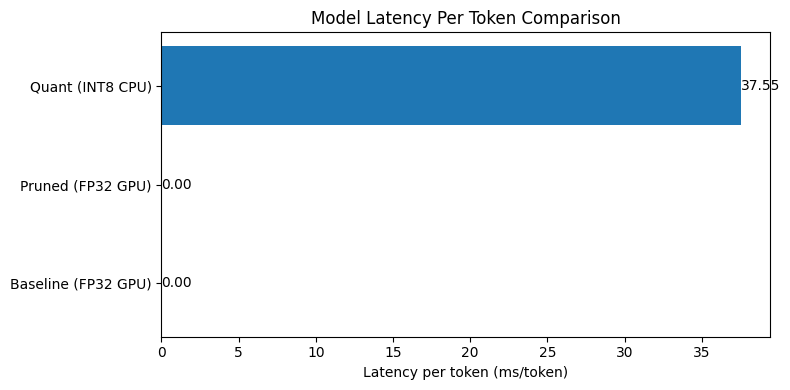

In [36]:
import matplotlib.pyplot as plt

def plot_latency(metrics):
    """
    Plots a horizontal bar chart of latency values from different optimization stages.

    Args:
        metrics (dict): A dictionary containing model stages as keys and dictionaries as values.
                        Each inner dictionary should contain a 'latency' field indicating the
                        latency in milliseconds per token. For example:

                        {
                            "Baseline (FP16 GPU)": {"latency": 12.5, "ppl": 40.03, "vram": 7.5},
                            "Pruned (FP16 GPU)":   {"latency": 10.2, "ppl": 55.54, "vram": 6.0},
                            "Quant (INT8 CPU)":    {"latency": 18.7, "ppl": 51.0,  "ram": 3.2}
                        }

    Returns:
        None. Displays a horizontal bar chart showing latency across optimization stages.

    TODO:
        1. Extract stage names from the metrics dictionary.
        2. Extract corresponding latency values for each stage.
        3. Use `matplotlib.pyplot` to create a horizontal bar chart.
        4. Label the x-axis as "Latency (ms/token)" and give an appropriate chart title.
        5. Annotate each bar with its exact latency value using `plt.text()`.
    """
    # 1. Extract stage names
    stages = list(metrics.keys())

    # 2. Extract latency values
    latencies = [
        metrics[stage]["latency_per_token"]
        for stage in stages
    ]

    # 3. Create horizontal bar chart
    plt.figure(figsize=(8, 4))

    bars = plt.barh(stages, latencies)

    # 4. Labels and title
    plt.xlabel("Latency per token (ms/token)")
    plt.title("Model Latency Per Token Comparison")

    # 5. Annotate bars
    for bar, latency in zip(bars, latencies):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f"{latency:.2f}",
            va="center",
            ha="left",
        )

    plt.tight_layout()
    plt.show()

plot_latency(metrics)

### Plot Memory Usage (GPU VRAM vs CPU RAM)

Baseline (FP32 GPU): ['latency_per_token', 'ppl', 'vram']
Pruned (FP32 GPU): ['latency_per_token', 'ppl', 'vram']
Quant (INT8 CPU): ['latency_per_token', 'ppl', 'ram']


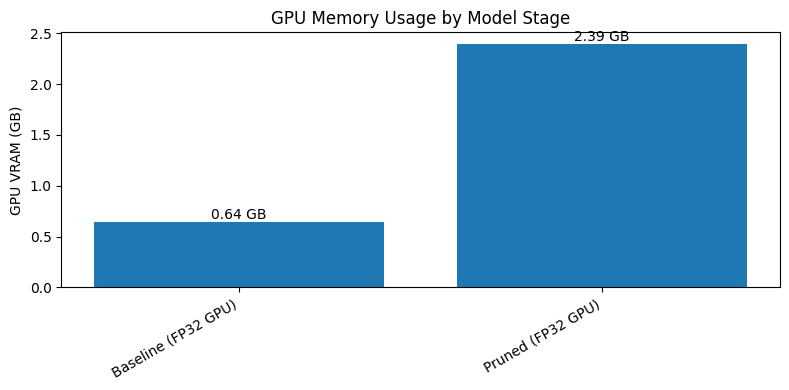

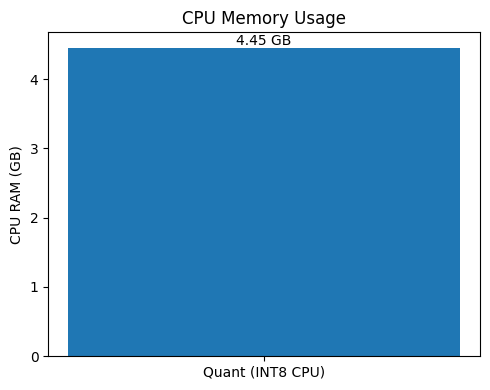

In [37]:
import matplotlib.pyplot as plt

def plot_memory_usage(metrics):
    """
    Plots two separate bar charts:
      1. GPU VRAM usage for all stages that include a 'vram' key.
      2. CPU RAM usage for the stage named 'Quant (INT8 CPU)' which includes a 'ram' key.

    Args:
        metrics (dict): A dictionary of performance metrics per stage. Each key is a stage name,
                        and each value is a dictionary that may include:
                            - 'vram': GPU memory in GB
                            - 'ram':  CPU memory in GB
                            - Other metrics like 'latency', 'ppl', etc.

    Returns:
        None. Displays memory usage bar charts.

    TODO:
        1. Extract and print all stages and their keys for debugging.
        2. Filter out only those stages that include the 'vram' key.
        3. Plot GPU memory (VRAM) usage for those stages.
        4. If the stage "Quant (INT8 CPU)" has a 'ram' key, plot CPU RAM usage.
    """
    # 1. Debug print
    for stage, values in metrics.items():
        print(f"{stage}: {list(values.keys())}")

    # 2. Filter stages with VRAM
    vram_stages = [
        stage for stage in metrics
        if "vram" in metrics[stage]
    ]

    vram_values = [
        metrics[stage]["vram"]
        for stage in vram_stages
    ]

    # 3. Plot GPU VRAM usage
    if vram_stages:
        plt.figure(figsize=(8, 4))
        bars = plt.bar(vram_stages, vram_values)

        plt.ylabel("GPU VRAM (GB)")
        plt.title("GPU Memory Usage by Model Stage")
        plt.xticks(rotation=30, ha="right")

        for bar, value in zip(bars, vram_values):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:.2f} GB",
                ha="center",
                va="bottom",
            )

        plt.tight_layout()
        plt.show()

    # 4. Plot CPU RAM usage for quantized CPU model
    if (
        "Quant (INT8 CPU)" in metrics
        and "ram" in metrics["Quant (INT8 CPU)"]
    ):
        ram_value = metrics["Quant (INT8 CPU)"]["ram"]

        plt.figure(figsize=(5, 4))
        bar = plt.bar(["Quant (INT8 CPU)"], [ram_value])

        plt.ylabel("CPU RAM (GB)")
        plt.title("CPU Memory Usage")

        plt.text(
            0,
            ram_value,
            f"{ram_value:.2f} GB",
            ha="center",
            va="bottom",
        )

        plt.tight_layout()
        plt.show()

plot_memory_usage(metrics)

### Plot Perplexity Comparison

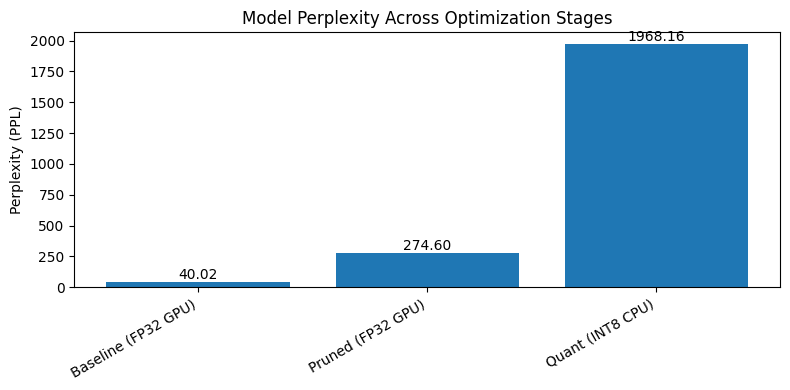

In [38]:
import matplotlib.pyplot as plt

def plot_perplexity(metrics):
    """
    Plots a bar chart showing perplexity values across different model optimization stages.

    Args:
        metrics (dict): A dictionary where keys are stage names and values are dictionaries
                        containing various performance metrics. Each stage dictionary should
                        include a 'ppl' (perplexity) key. For example:

                        {
                            "Baseline (FP16 GPU)": {"latency": 12.5, "ppl": 40.03, "vram": 7.5},
                            "Pruned (FP16 GPU)":   {"latency": 10.2, "ppl": 55.54, "vram": 6.0},
                            "Quant (INT8 CPU)":    {"latency": 18.7, "ppl": 51.0,  "ram": 3.2}
                        }

    Returns:
        None. Displays a bar chart of perplexity values.

    TODO:
        1. Extract stage names from the metrics dictionary.
        2. Extract corresponding perplexity values for each stage.
        3. Use `matplotlib.pyplot` to plot a vertical bar chart.
        4. Annotate each bar with the corresponding perplexity value.
    """
    # 1. Extract stage names
    stages = list(metrics.keys())

    # 2. Extract perplexity values
    perplexities = [
        metrics[stage]["ppl"]
        for stage in stages
    ]

    # 3. Plot bar chart
    plt.figure(figsize=(8, 4))
    bars = plt.bar(stages, perplexities)

    # 4. Labeling
    plt.ylabel("Perplexity (PPL)")
    plt.title("Model Perplexity Across Optimization Stages")
    plt.xticks(rotation=30, ha="right")

    # Annotate each bar
    for bar, ppl in zip(bars, perplexities):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{ppl:.2f}",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

plot_perplexity(metrics)

#### Generate FLAME graphs using Tensorboard

### Run inference on CPU to predict next word

In [39]:
import torch
import torch.nn.functional as F

def get_next_token_suggestions(
    model,
    tokenizer,
    prompt: str,
    top_k: int = 5
):
    """
    Returns the top_k most likely next‐token suggestions for a given prompt,
    based on the quantized CPU model’s logits.

    Args:
      model (INCModelForCausalLM): quantized GPT-2 on CPU
      tokenizer (AutoTokenizer): matching tokenizer
      prompt (str): the input text so far
      top_k (int): how many token suggestions to return

    Returns:
      List of (token_str, probability) tuples, sorted by descending probability.
    """
    # TODO: Implement the function to get next token suggestions
    # Eval mode
    model.eval()

    # Tokenize prompt
    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    with torch.inference_mode():

        # Forward pass
        outputs = model(**inputs)

        # Logits for the LAST token position
        # Shape: [batch, seq_len, vocab_size]
        logits = outputs.logits

        next_token_logits = logits[:, -1, :]

        # Convert logits -> probabilities
        probs = F.softmax(next_token_logits, dim=-1)

        # Top-k selection
        top_probs, top_indices = torch.topk(
            probs,
            k=top_k,
            dim=-1
        )

    # Convert token IDs -> strings
    suggestions = []

    for token_id, prob in zip(
        top_indices[0],
        top_probs[0]
    ):
        token_str = tokenizer.decode(token_id)

        suggestions.append(
            (token_str, prob.item())
        )

    return suggestions


prompt_text = "Chelsea Football Club will win the Champions League and"
suggestions = get_next_token_suggestions(
    quant_model_cpu,
    tokenizer,
    prompt_text,
    top_k=3
)

print(f"Prompt: {prompt_text!r}\n")
print("Next-word suggestions (token ⟶ probability):")
for token_str, prob in suggestions:
    print(f"  {token_str!r} ⟶ {prob:.4f}")

Prompt: 'Chelsea Football Club will win the Champions League and'

Next-word suggestions (token ⟶ probability):
  '\n' ⟶ 0.0201
  ' and' ⟶ 0.0189
  ',' ⟶ 0.0182


# Download Files from Google Colab
If running the this notebook on google colab then run the following cells 1 by1 to download the models and files


In [43]:
# List all the folders in /content with file size

!du -sh /content/*

22M	/content/baseline_fp32_trace.json
477M	/content/gpt2_original
481M	/content/gpt2_original_ov_fp32
124M	/content/gpt2_original_unpruned_quantized
445M	/content/gpt2_ov_fp32
441M	/content/gpt2_pruned
4.0K	/content/gpt2_pruned_finetuned
114M	/content/gpt2_pruned_finetuned_quantized
280M	/content/logs
32M	/content/pruned_fp32_trace.json
55M	/content/sample_data


In [44]:
# The model directories could be huge
# Create a tar.gz archive (better compression)
# This is often smaller and faster than ZIP.

!tar -czvf /content/backup.tar.gz /content/*

tar: Removing leading `/' from member names
/content/baseline_fp32_trace.json
tar: Removing leading `/' from hard link targets
/content/gpt2_original/
/content/gpt2_original/generation_config.json
/content/gpt2_original/tokenizer_config.json
/content/gpt2_original/model.safetensors
/content/gpt2_original/merges.txt
/content/gpt2_original/special_tokens_map.json
/content/gpt2_original/config.json
/content/gpt2_original/vocab.json
/content/gpt2_original_ov_fp32/
/content/gpt2_original_ov_fp32/tokenizer.json
/content/gpt2_original_ov_fp32/generation_config.json
/content/gpt2_original_ov_fp32/openvino_model.bin
/content/gpt2_original_ov_fp32/tokenizer_config.json
/content/gpt2_original_ov_fp32/merges.txt
/content/gpt2_original_ov_fp32/special_tokens_map.json
/content/gpt2_original_ov_fp32/openvino_model.xml
/content/gpt2_original_ov_fp32/config.json
/content/gpt2_original_ov_fp32/vocab.json
/content/gpt2_original_unpruned_quantized/
/content/gpt2_original_unpruned_quantized/generation_conf

In [45]:
# Download the zipped file from google colab
from google.colab import files
files.download('/content/backup.tar.gz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>